# Master Thesis - Recreation for all: Making nature-based accommodations discoverable for public transport users
Alischa Thomas - 2025 - Aalto University

### Project Setup
- Language: Python
- Virtual Environment: Conda. Packages were installed in the environment and only need to be imported to the script via the cells below.
- Juypter Notebook

To execute the code, first activate the virtual conda environment with -> conda activate thesis_env

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating and Cleaning Dataset

In [ ]:
# Import the raw data into a dataframe

# store csv to dataframe
df_task_performance = pd.read_csv("src/raw_data_task_performance_working_file.csv")
# inspect dataframe
# df_reachability
# check data type for cells
df_task_performance.dtypes

# Transpose dataframe
df_task_performance_trans = df_task_performance.T
# df_task_performance_trans

# Clean column names
col_names = ["Task success", "Min travel tolerance (min)", "Max travel tolerance (min)", "Expected trip travel time", "Actual trip travel time", "Diff. expected-actual trip travel time", "Task start", "Task end", "Task conduction time", "Platform count", "Mental load"]
# col_names
df_task_performance_trans.columns = col_names

# Removes unrequired columns and rows
df_task_performance_trans = df_task_performance_trans.drop(index=["Variable"])
df_task_performance_trans = df_task_performance_trans.drop(columns=["Task start", "Task end"])
df_task_performance_trans
# df_task_performance_trans.dtypes

# inspect data types per col
df_types = df_task_performance_trans.map(type)
df_types

# converting data types
cols_to_numeric = ["Min travel tolerance (min)", "Max travel tolerance (min)", "Expected trip travel time", "Actual trip travel time", "Diff. expected-actual trip travel time", "Platform count", "Mental load"]
df_task_performance_trans[cols_to_numeric] = df_task_performance_trans[cols_to_numeric].apply(pd.to_numeric)
# converts conduction time to datetime in min format
df_task_performance_trans["Task conduction time"] = df_task_performance_trans["Task conduction time"].apply(pd.to_datetime).dt.time
#df_task_performance_trans["Task conduction time"] = pd.to_datetime(df_task_performance_trans["Task conduction time"]).dt.time


df_task_performance_trans["Task success"] = df_task_performance_trans["Task success"].map({"T": True, "F": False})
df_types = df_task_performance_trans.map(type)
df_types
df_task_performance_trans


,Task success,Min travel tolerance (min),Max travel tolerance (min),Expected trip travel time,Actual trip travel time,Diff. expected-actual trip travel time,Task conduction time,Platform count,Mental load
P1,True,60,180,150,162,12,00:14:03,2,32
P2,False,60,210,150,207,57,00:30:30,7,85
P3,True,60,240,240,271,31,00:18:23,4,32
P4,True,90,420,250,296,46,00:22:25,6,25
P5,True,15,120,120,153,33,00:08:57,4,38
P6,True,30,150,80,85,5,00:20:50,3,30
P7,True,40,180,180,184,4,00:19:10,5,57


# Plotting

## Platform Count

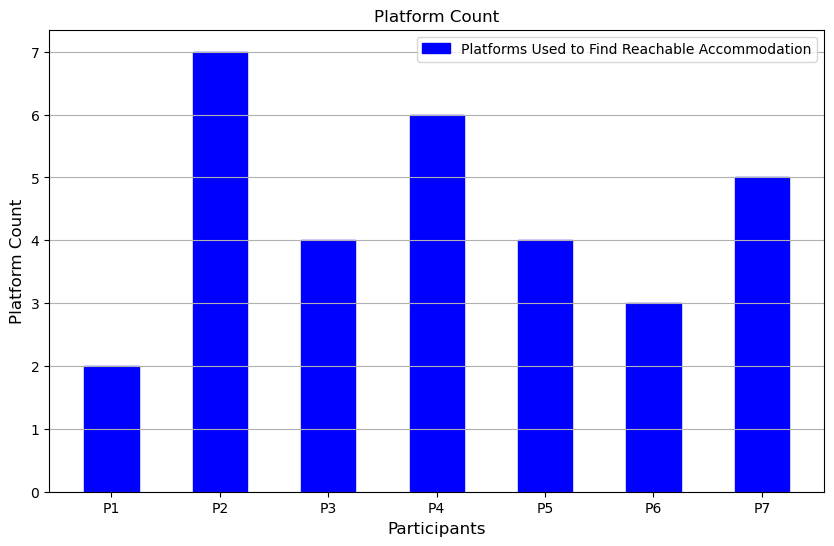

In [70]:
# Platform count
plt.figure(figsize=(10, 6))

# Make the plot
plt.bar(df_task_performance_trans.index, df_task_performance_trans["Platform count"], color ='blue', width = 0.5,
            edgecolor ='blue', label ='Platforms Used to Find Reachable Accommodation')

plt.ylabel('Platform Count', fontsize = 12)
plt.xlabel('Participants', fontsize = 12)

plt.title('Platform Count')

plt.legend()
plt.grid(axis="y")
plt.show()